<a href="https://colab.research.google.com/github/HanifFaishalH/AlgoritmaStrukturData/blob/Hilmi/Week6_15.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Nama :** Hanif Faishal Hilmi

**Kelas :** TI-3F

**NIM :** 2341720116

# Praktikum Filter Spasial Low Pass Filter, High Pass Filter, Point Detection, Line Detection, Edge Detection

## D. PRAKTIKUM FILTER

### Membuat fungsi konvolusi menggunakan algoritma yang telah dijelaskan pada Bagian C, tanpa menggunakan library atau metode konvolusi dari OpenCV.  

1. Akses file yang terdapat pada drive dan import beberapa library yang dibutuhkan

In [1]:
from google.colab import drive
drive.mount('/content/MyDrive')

Drive already mounted at /content/MyDrive; to attempt to forcibly remount, call drive.mount("/content/MyDrive", force_remount=True).


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2 as cv
import math
from google.colab.patches import cv2_imshow
from PIL import Image as im

2. Buatlah fungsi konvolusi. Catatan: parameter yang digunakan boleh dimodifikasi. Misal, hanya menggunakan parameter image dan kernel saja, atau image, kernel, dan
padding.

In [3]:
import numpy as np

# image: Matriks 2D yang merepresentasikan citra input.
# kernel: Matriks 2D (biasanya lebih kecil dari citra) yang berfungsi sebagai filter.
# stride: Jumlah piksel pergeseran kernel pada setiap langkah.
# padding: Jumlah lapisan piksel bernilai nol yang ditambahkan di sekeliling citra.
def convolution2d(image, kernel, stride, padding):
  # 1. Menambahkan 'padding' (bingkai nol) di sekeliling citra.
  if padding > 0:
    image_padded = np.pad(image, pad_width=padding, mode='constant', constant_values=0)
  else:
    image_padded = image

  # 2. Mendapatkan dimensi dari citra yang sudah diberi padding dan dimensi kernel.
  (image_height, image_width) = image_padded.shape
  (kernel_height, kernel_width) = kernel.shape

  # 3. Menghitung dimensi matriks output berdasarkan rumus konvolusi.
  output_height = int((image_height - kernel_height) / stride) + 1
  output_width = int((image_width - kernel_width) / stride) + 1

  # 4. Membuat matriks output baru yang diisi dengan nilai nol.
  output = np.zeros((output_height, output_width))

  # 5. Lakukan perulangan untuk menggeser kernel ke seluruh bagian citra.
  for y in range(0, output_height):
    for x in range(0, output_width):
      # Tentukan posisi 'jendela' atau potongan pada citra input.
      start_y = y * stride
      end_y = start_y + kernel_height
      start_x = x * stride
      end_x = start_x + kernel_width

      # Ambil potongan (slice) dari citra sesuai posisi jendela.
      image_slice = image_padded[start_y:end_y, start_x:end_x]

      # 6. Hitung nilai untuk satu piksel output:
      #    - Lakukan perkalian elemen-demi-elemen antara potongan citra dan kernel.
      #    - Jumlahkan semua hasil perkalian tersebut.
      #    Komentar sebelumnya kurang tepat, ini adalah inti perhitungan, bukan 'konvolusi pada potongan'.
      output[y, x] = np.sum(image_slice * kernel)

  return output

* Load image yang akan diproses

In [4]:
img = cv.imread('/content/MyDrive/MyDrive/PCVK25_3F_15/image/Pertemuan6/mandrill.tiff')
img_gray = cv.cvtColor(img, cv.COLOR_BGR2GRAY)

* Tentukan kernel yang akan digunakan

In [5]:
kernel_sharpen = np.array([[0, -1, -0],
                           [-1, 9, -1],
                           [0, -1, 0]])

* Memanggil fungsi konvolusi yang telah dibuat sebelumnya, dan menampilkan hasil
konvolusinya:

In [6]:
convolution2d(img_gray,kernel_sharpen,1,2)

array([[   0., -145.,  -56., ..., -153., -177.,    0.],
       [-145., 1133.,  209., ...,  938., 1315., -177.],
       [-116.,  721.,  583., ...,  845.,  718., -125.],
       ...,
       [-156., 1111.,  826., ...,  479.,  459.,  -69.],
       [ -11.,  -68.,  -66., ...,  -55.,  -37.,   -4.],
       [   0.,  -11.,  -11., ...,   -4.,   -4.,    0.]])

3. Membuat Image Filter untuk Average filter, low pass filter, high pass filter, dan beberapa filter lainnya


In [7]:
# operasi sharpen
sharpen_kernel = np.array([[0, -1, -0],
                           [-1, 5, -1],
                           [0, -1, 0]])
# operasi emboss
emboss_kernel = np.array([[-2, -1, -0],
                           [-1, 1, 1],
                           [0, 1, 2]])

# operasi Left Sobel Edge Detection
lsed_kernel = np.array([[1, 0, -1],
                        [2, 0, -2],
                        [1, 0, -1]])

# operasi Canny Edge Detection
ced_kernel = np.array([[-1, -1, -1],
                        [-1, 8, -1],
                        [-1, -1, -1]])

# operasi 21 x 21 Gaussian Blur
kernel_size = 21
sigma = math.sqrt(kernel_size)
gaussian_kernel = cv.getGaussianKernel(kernel_size, sigma)
gauss_kernel = gaussian_kernel @ gaussian_kernel.transpose()

In [8]:
# eksekusi semua kodenya
sharpen_img = convolution2d(img_gray, sharpen_kernel, 1, 2)
emboss_img = convolution2d(img_gray, emboss_kernel, 1, 2)
lsed_img = convolution2d(img_gray, lsed_kernel, 1, 2)
ced_img = convolution2d(img_gray, ced_kernel, 1, 2)
gauss_img = convolution2d(img_gray, gauss_kernel, 1, 2)

# buat semua hasil filter menjadi list
filters = {
    "Sharpen": sharpen_img,
    "Emboss": emboss_img,
    "Left Sobel Edge Detection": lsed_img,
    "Canny Edge Detection": ced_img,
    "Gaussian Blur": gauss_img
}

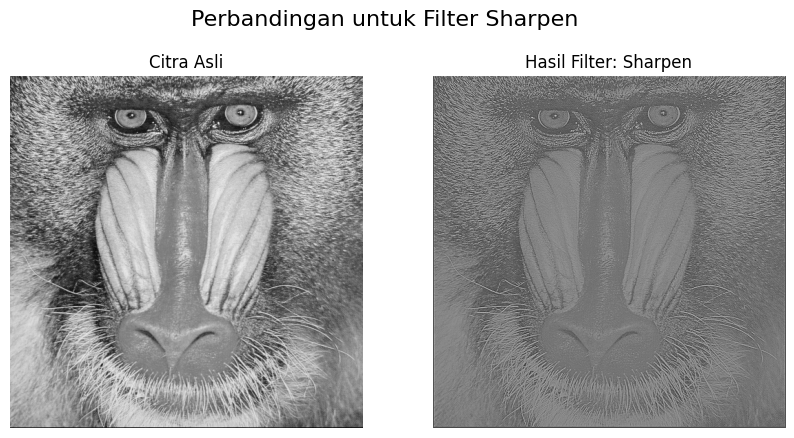

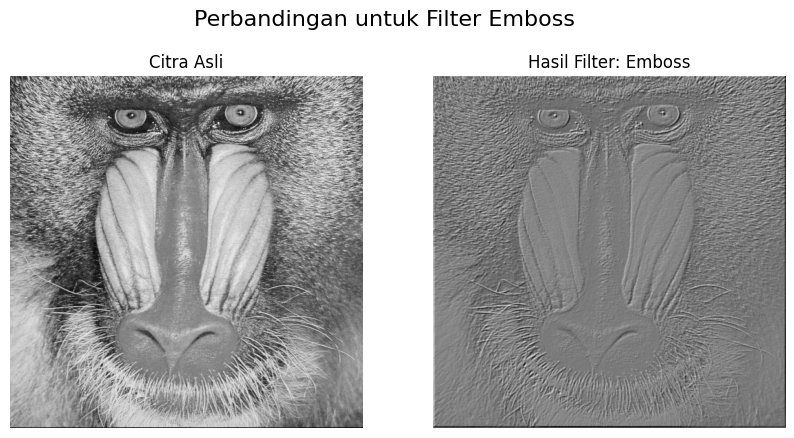

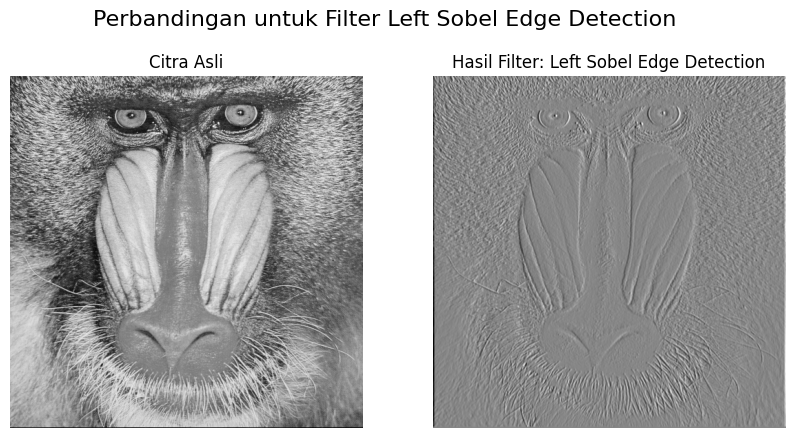

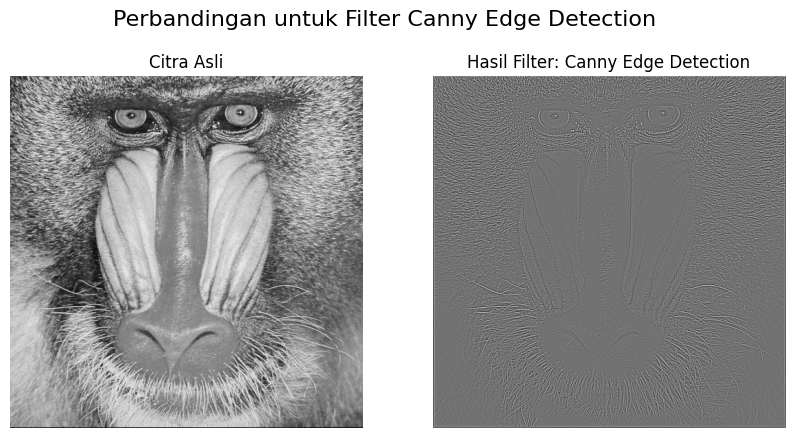

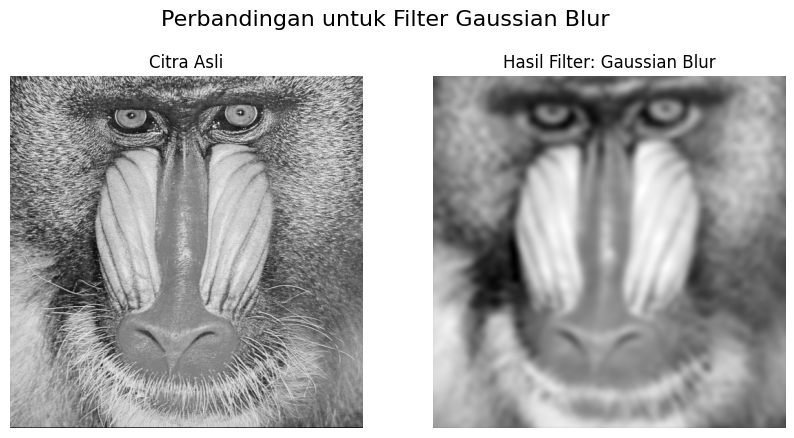

In [9]:
# Menampilkan plot hasil
# Membuat plot untuk setiap filter
for filter_name, filtered_image in filters.items():
    plt.figure(figsize=(10, 5))

    # Plot Citra Asli
    plt.subplot(1, 2, 1)
    plt.imshow(img_gray, cmap='gray')
    plt.title('Citra Asli')
    plt.axis('off')

    # Plot Citra Hasil Filter
    plt.subplot(1, 2, 2)
    plt.imshow(filtered_image, cmap='gray')
    plt.title(f'Hasil Filter: {filter_name}')
    plt.axis('off')

    plt.suptitle(f'Perbandingan untuk Filter {filter_name}', fontsize=16)
    plt.show()
